## Mateus Ribeiro Gomes - 555225
### Trabalho Densidade Espectral de Potência

In [1]:
import numpy as np
from matplotlib import pyplot as plt

### 1a questão

O valor de $A$ escolhido para utilizar na equação $s_{int}(n) = A \cdot cos(2 \pi f_0 n + \phi)$ foi $A = \sqrt{2}$ para que a interferência do canal adjacente tenha mesma potência que o ruído (unitária).

Potência ($P$) de uma senoide com aplitude $A$ é dada por: $$P = \frac{A^2}{2}$$

In [2]:
# Definindo os dados fornecidos
n1 = 1024
n2 = 4096
a1 = 1.35
a2 = -0.85
f0 = 0.45
phi = np.random.uniform(0, 2 * np.pi)
alpha = 0.72
D = 4

#### Função para gerar o 

#### $x(n) = a_1 \cdot x(n-1) + a_2 \cdot x(n-2) + u(n)$

In [3]:
gerar_ruido = lambda n, var : np.random.normal(0, np.sqrt(var), n)

def gerar_x(n):
    u = gerar_ruido(n, 1.0) 
    xret = np.zeros(n)
    for i in range(n):
        if i == 0:
            xret[i] = u[i]
        elif i == 1:
            xret[i] = a1 * xret[i-1] + u[i]
        else:
            xret[i] = a1 * xret[i-1] + a2 * xret[i-2] + u[i]
            
    return xret

#### Função para modelar o filtro FIR
#### $h(n) = \delta(n) + \alpha \cdot \delta (n-D)$

In [4]:
def aplicar_canal(x):
    y = np.zeros(len(x))
    # As primeiras D amostras não sofrem interferência 
    y[:D] = x[:D]
    # A partir de D, o sinal é a soma do caminho direto com o percurso atrasado
    y[D:] = x[D:] + alpha * x[:-D]
    return y

#### Função para a interferência
#### $s_{int}(n) = A \cdot cos(2 \pi f_0 n + \phi)$

In [5]:
def sint(n, A):
    return A * np.cos(2*np.pi*f0*n + phi)

#### Função para calcular a variância dada as diferentes relações sinal ruído
#### $SNR_{db} = 10 \cdot log_{10} \cdot \frac{P_{signal}}{P_{noise}}$, queremos achar o $P_{noise}$

In [6]:
def var_given_db(y, db):
    pot = np.mean(y**2)
    var = pot / (10**(db/10))
    return var

#### Função final que combina tudo

Semelhante a escolhe de $A = $, foi escolhido $\sigma_w ^ 2 = 1$ para que a potência do AWGN fosse igual ao ruído presnete em $x(n)$

In [7]:
def ar2(n, A, snr_db=None, var_w_direto=None):
    xtemp = gerar_x(n)
    y = aplicar_canal(xtemp)
    if var_w_direto is not None:
        var_final = var_w_direto
    elif snr_db is not None:
        var_final = var_given_db(y, snr_db)
    else:
        raise ValueError("Voce deve fornecer ou snr_db ou var_w_direto")
    sinterf = sint(np.arange(n), A)
    w = gerar_ruido(n, var_final)
    r = y + sinterf + w
    return r, var_final

In [8]:
ar_1024 = ar2(n=n1, A=np.sqrt(2), var_w_direto=1)
ar_4096 = ar2(n=n2, A=np.sqrt(2), var_w_direto=1)

#### Plotando

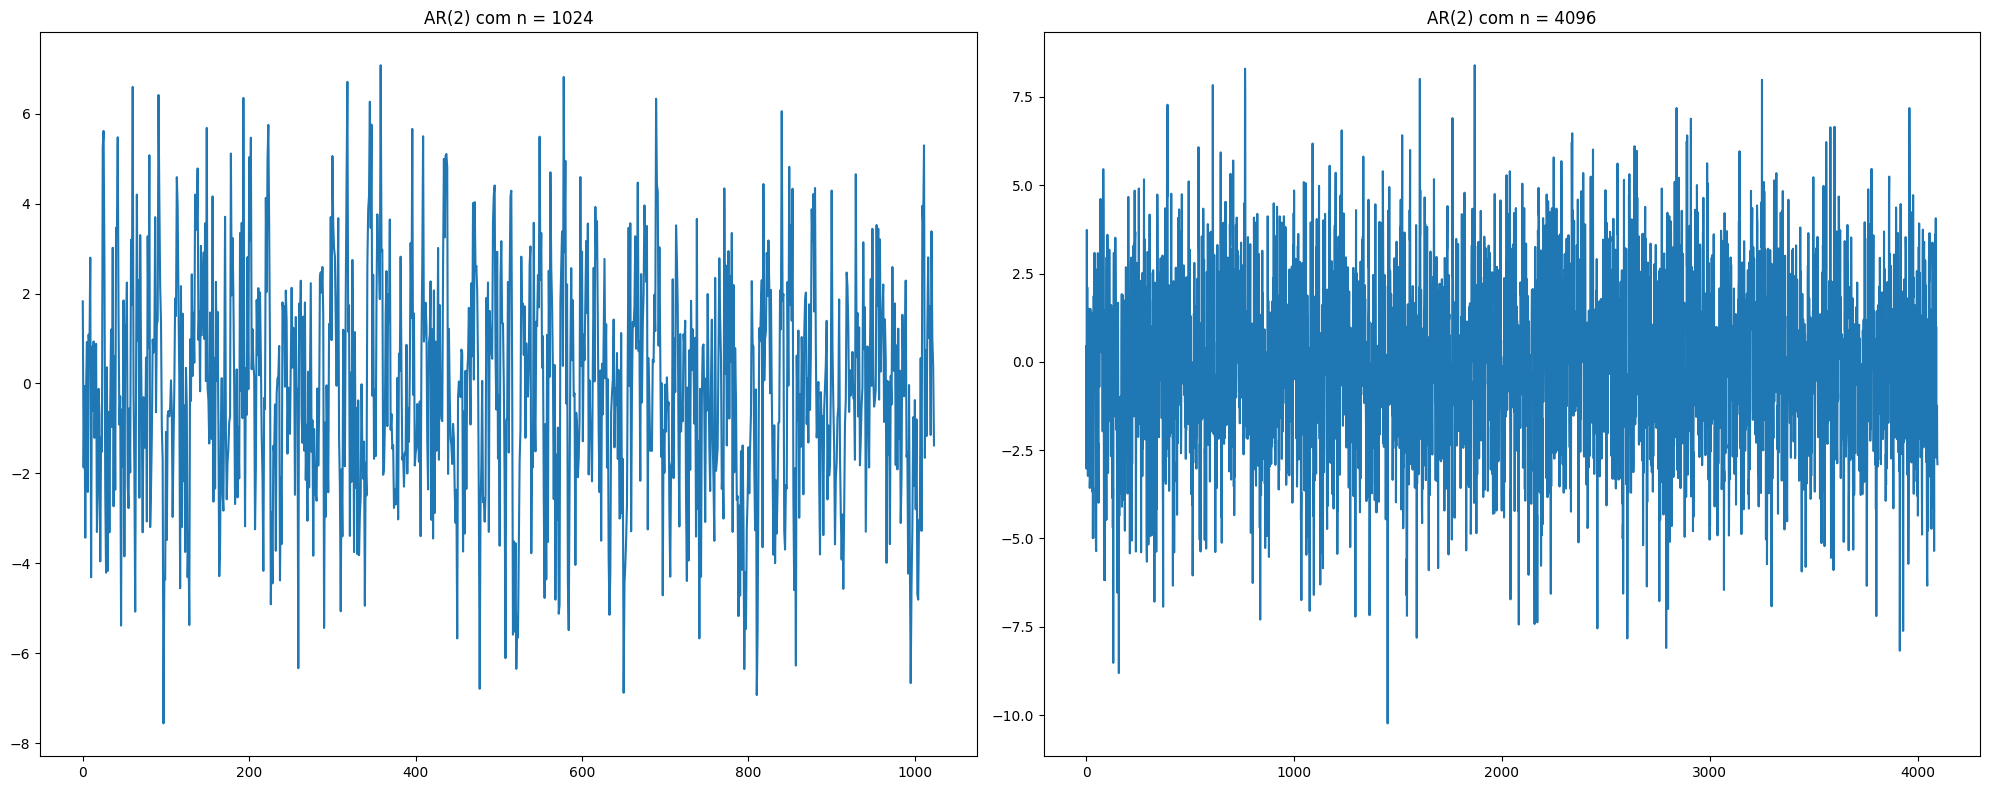

In [9]:
N1 = np.arange(n1)
N2 = np.arange(n2)

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

axs[0].plot(N1, ar_1024[0])
axs[0].set_title('AR(2) com n = 1024')

axs[1].plot(N2, ar_4096[0])
axs[1].set_title('AR(2) com n = 4096')

plt.tight_layout()
plt.show()

## 2a questão

#### Variando os valores de "A" e $\sigma^2_w$

Os valores escolhidos foram:

#### 1. Amplitudes de Interferência A

As escolhas foram feitas visando diferentes cenários de potência da interferência do canal adjacente $P = \frac{A^2}{2}$

* **A = 0.5**: Interferência fraca com potência 0.125. Serve como linha de base para observar o formato do espectro original com distorções mínimas.

* **A = $\sqrt{2}$**: Cenário de potência unitária. Estabelece um equilíbrio energético perfeito, igualando a força da interferência à variância do ruído gaussiano original.

* **A = 5**: Interferência severa com potência 12.5. O tom senoidal domina o espectro e reduz a margem dinâmica de visualização do sinal de dados.

* **A = 10**: Interferência extrema com potência 50. Testa o limite de falha do algoritmo, esmagando completamente o sinal útil no gráfico.

#### 2. Variância ajustável $\sigma_w ^ 2$

As escolhas foram feitas visando difentes signal-noise ratio $SNR_{db} = 10 \cdot log_{10} \cdot \frac{P_{signal}}{P_{noise}}$

* **0 dB**: Degradação máxima. A potência do ruído é exatamente igual à potência do sinal recebido, mascarando as frequências do sistema.

* **10 dB**: Condição nominal. Canal de comunicação realista com ruído perceptível, exigindo eficiência do método para detectar a informação.

* **30 dB**: Canal de alta qualidade. Ruído baixo, excelente para validar visualmente a resposta em frequência pura do filtro FIR.

* **50 dB**: Condição teórica ideal. O fundo de ruído é empurrado para o mínimo computacional possível, permitindo visualizar as ondulações "limpas".

In [10]:
As = [0.5, np.sqrt(2), 5, 10]
dbs = [0, 10, 30, 50]
# ar2s_1024 = [ar2(n1,a, db) for a in As for db in dbs]
# ar2s_4096 = [ar2(n2,a, db) for a in As for db in dbs]

sinais_1024 = []
sinais_4096 = []

linhas_1024 = []
linhas_4096 = []

w1, w2, w3, w4 = 14, 19, 21, 28

for a in As:
    for db in dbs:
        r_1024, var_1024 = ar2(n1, a, snr_db=db)
        sinais_1024.append((a, db, r_1024))
        
        r_4096, var_4096 = ar2(n2, a, snr_db=db)
        sinais_4096.append((a, db, r_4096))
        
        a_str = f"√2" if np.isclose(a, np.sqrt(2)) else f"{a:.1f}"
        
        linhas_1024.append(f"| {'1024':^{w1}} | {a_str:^{w2}} | {db:^{w3}} | {var_1024:^{w4}.4f} |")
        linhas_4096.append(f"| {'4096':^{w1}} | {a_str:^{w2}} | {db:^{w3}} | {var_4096:^{w4}.4f} |")


print(f"| {'N':^{w1}} | {'A':^{w2}} | {'SNR utilizado (dB)':^{w3}} | {'Variância ajustável (σ²_w)':^{w4}} |")
print(f"|{'-'*(w1+2)}|{'-'*(w2+2)}|{'-'*(w3+2)}|{'-'*(w4+2)}|")

for linha in linhas_1024:
    print(linha)

for linha in linhas_4096:
    print(linha)

|       N        |          A          |  SNR utilizado (dB)   |  Variância ajustável (σ²_w)  |
|----------------|---------------------|-----------------------|------------------------------|
|      1024      |         0.5         |           0           |            4.3919            |
|      1024      |         0.5         |          10           |            0.4014            |
|      1024      |         0.5         |          30           |            0.0039            |
|      1024      |         0.5         |          50           |            0.0000            |
|      1024      |         √2          |           0           |            3.4025            |
|      1024      |         √2          |          10           |            0.4120            |
|      1024      |         √2          |          30           |            0.0042            |
|      1024      |         √2          |          50           |            0.0000            |
|      1024      |         5.0         |

### Plotando os casos gerados com todas as amostras

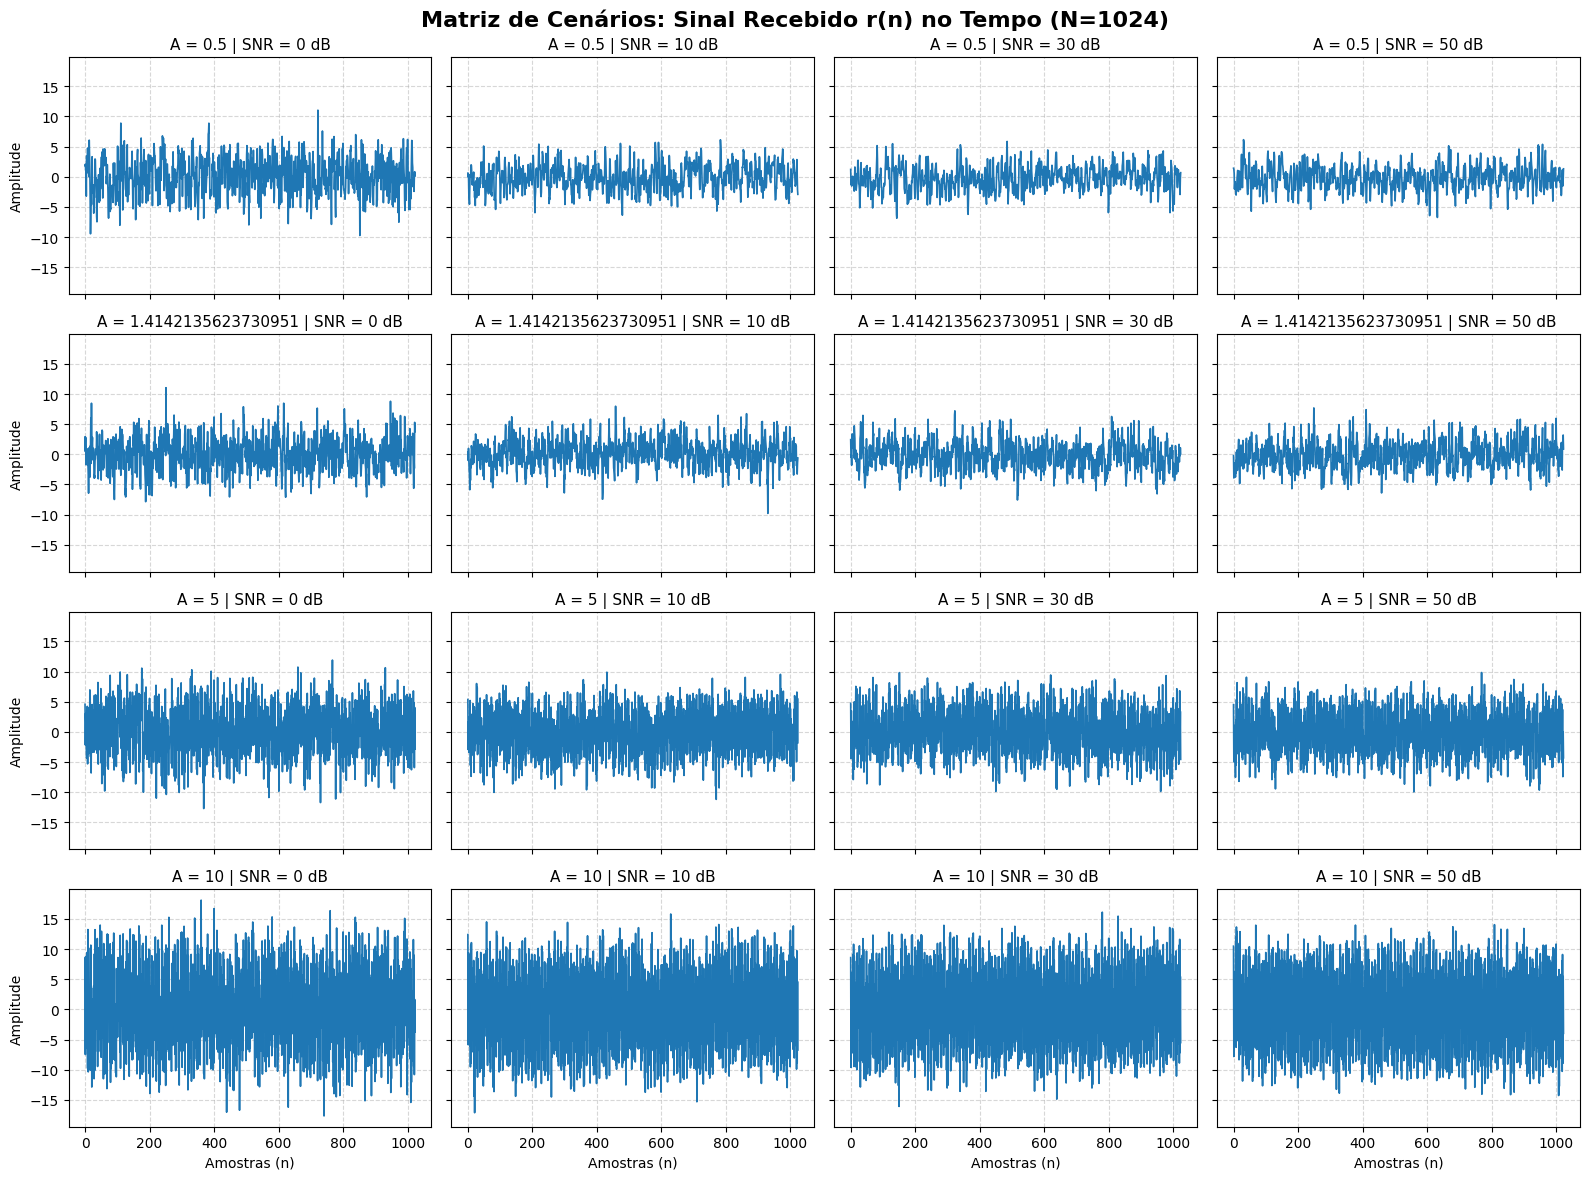

In [11]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('Matriz de Cenários: Sinal Recebido r(n) no Tempo (N=1024)', fontsize=16, fontweight='bold', y=0.98)

indice_sinal = 0

for i, a in enumerate(As):
    for j, db in enumerate(dbs):
        ax = axes[i, j]
        
        a_val, db_val, sinal_r = sinais_1024[indice_sinal]

        ax.plot(sinal_r, color='#1f77b4', linewidth=1.2)
        
        ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 3:
            ax.set_xlabel('Amostras (n)')
        if j == 0:
            ax.set_ylabel('Amplitude')
            
        indice_sinal += 1

plt.tight_layout()
plt.show()

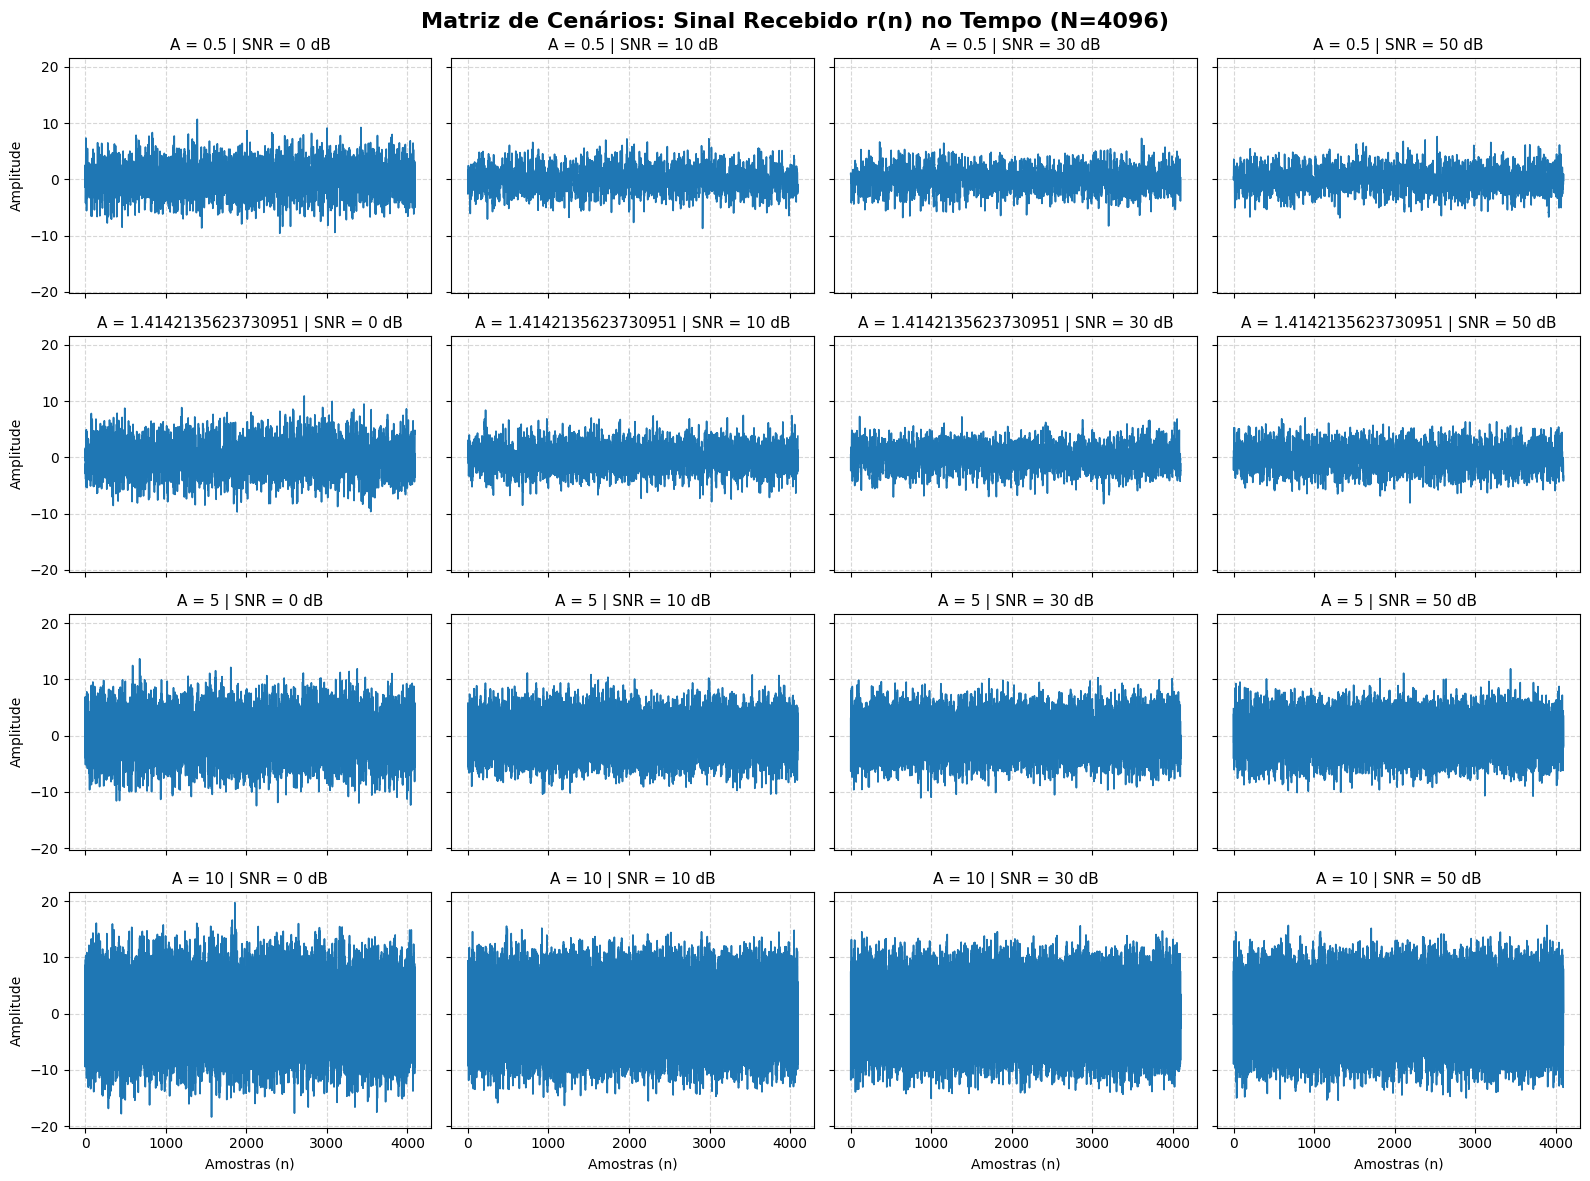

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('Matriz de Cenários: Sinal Recebido r(n) no Tempo (N=4096)', fontsize=16, fontweight='bold', y=0.98)

indice_sinal = 0

for i, a in enumerate(As):
    for j, db in enumerate(dbs):
        ax = axes[i, j]
        
        a_val, db_val, sinal_r = sinais_4096[indice_sinal]
        ax.plot(sinal_r, color='#1f77b4', linewidth=1.2)
        
        ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 3:
            ax.set_xlabel('Amostras (n)')
        if j == 0:
            ax.set_ylabel('Amplitude')
            
        indice_sinal += 1

plt.tight_layout()
plt.show()

### Plotando os casos gerados porém apenas as 100 primeiras amostras para melhor visualização

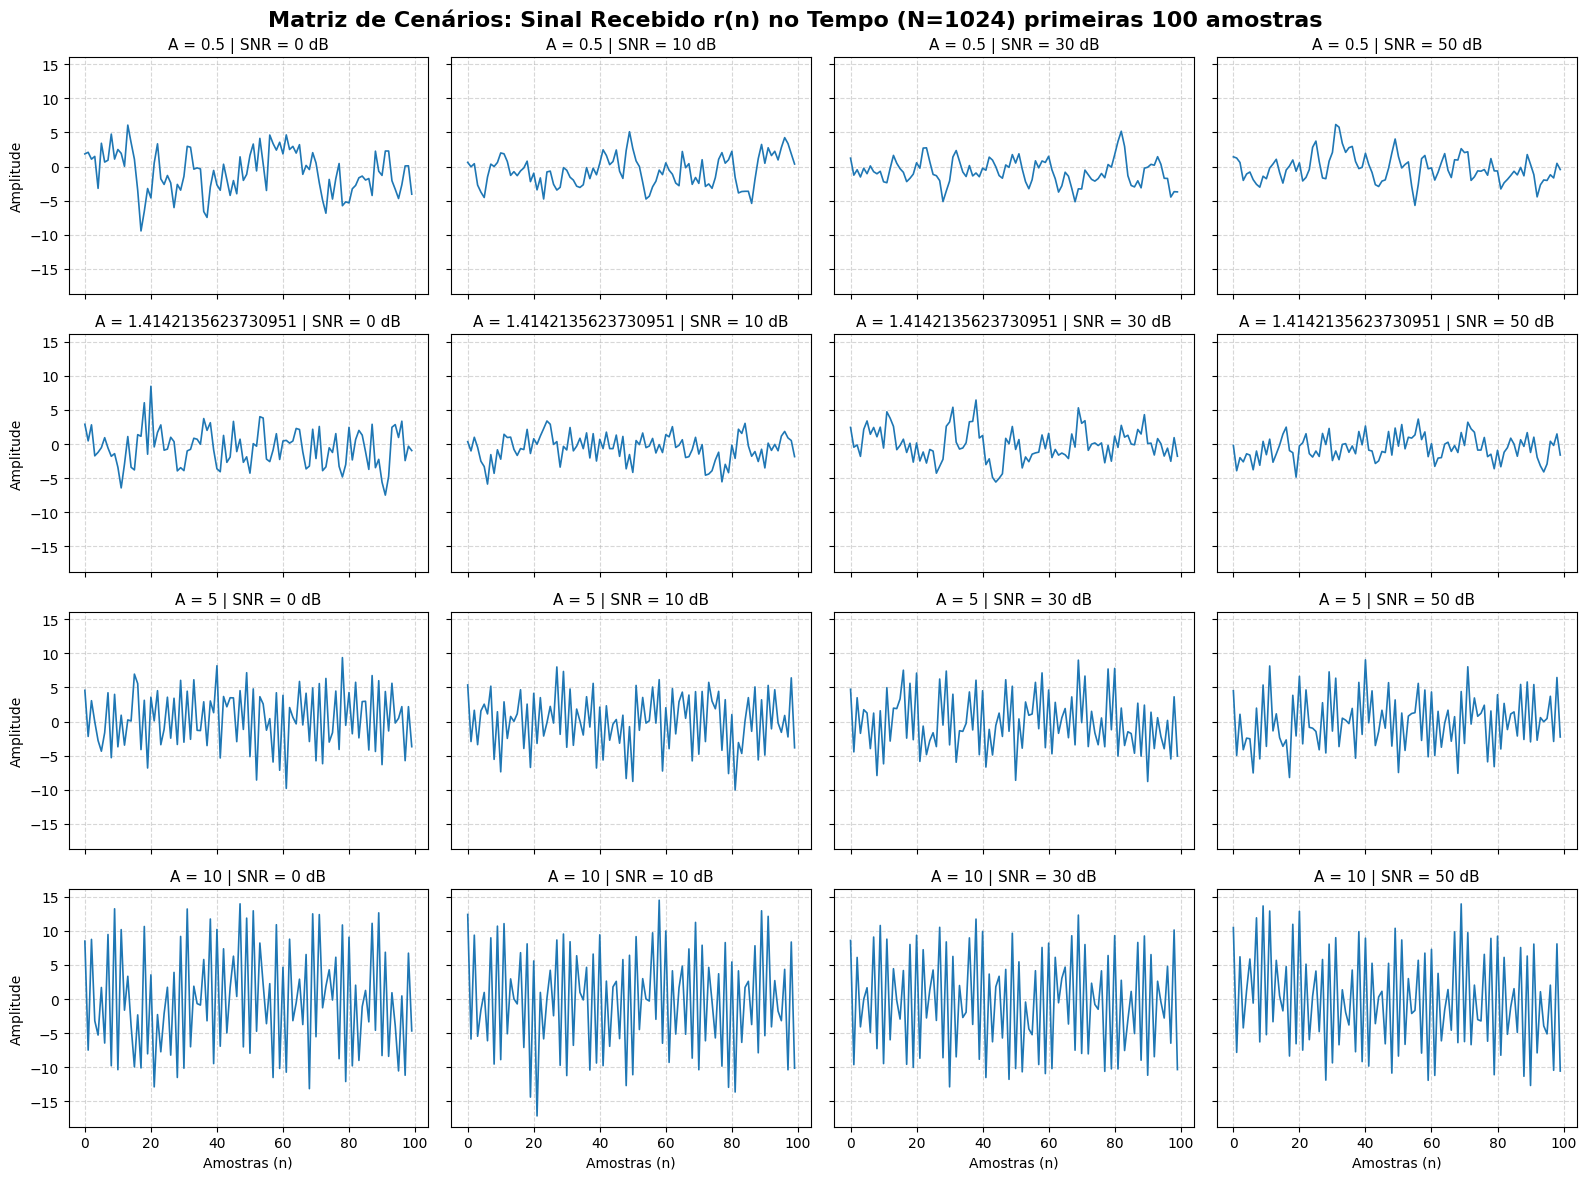

In [13]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('Matriz de Cenários: Sinal Recebido r(n) no Tempo (N=1024) primeiras 100 amostras', fontsize=16, fontweight='bold', y=0.98)

indice_sinal = 0

for i, a in enumerate(As):
    for j, db in enumerate(dbs):
        ax = axes[i, j]
        
        a_val, db_val, sinal_r = sinais_1024[indice_sinal]

        ax.plot(sinal_r[:100], color='#1f77b4', linewidth=1.2)
        
        ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 3:
            ax.set_xlabel('Amostras (n)')
        if j == 0:
            ax.set_ylabel('Amplitude')
            
        indice_sinal += 1

plt.tight_layout()
plt.show()

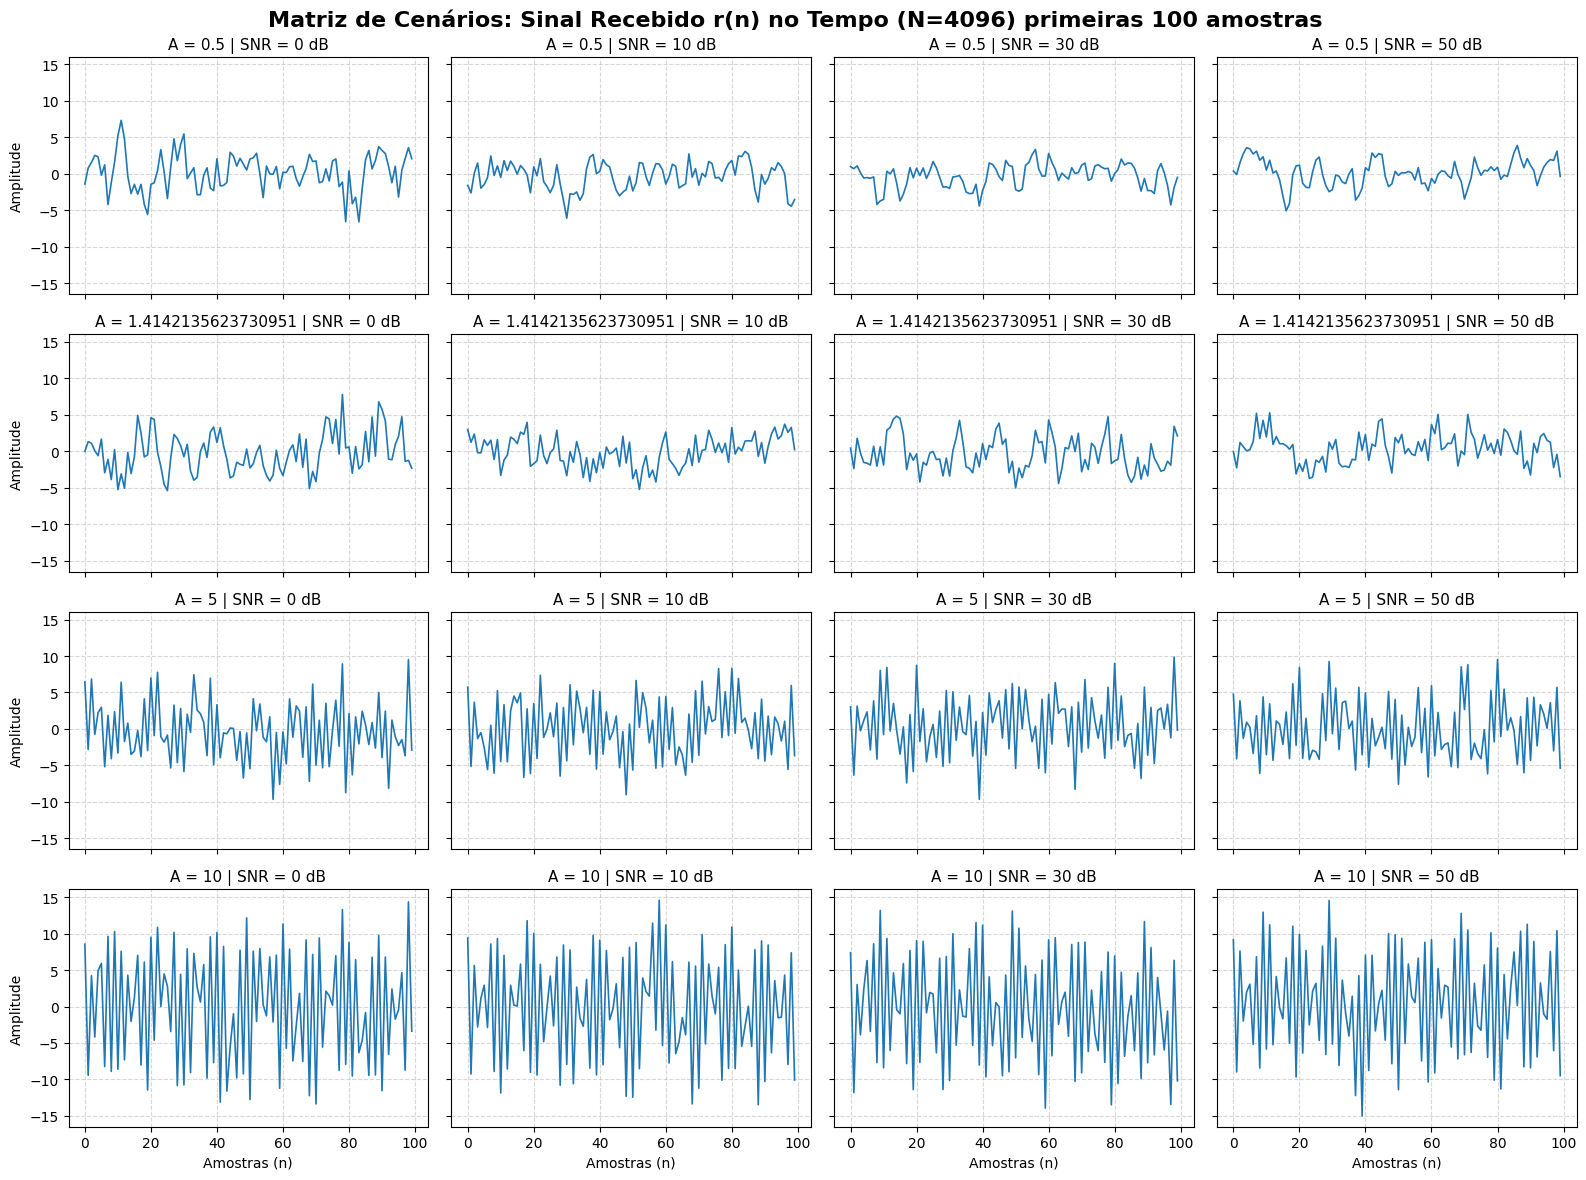

In [14]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle('Matriz de Cenários: Sinal Recebido r(n) no Tempo (N=4096) primeiras 100 amostras', fontsize=16, fontweight='bold', y=0.98)

indice_sinal = 0

for i, a in enumerate(As):
    for j, db in enumerate(dbs):
        ax = axes[i, j]
        
        a_val, db_val, sinal_r = sinais_4096[indice_sinal]
        ax.plot(sinal_r[:100], color='#1f77b4', linewidth=1.2)
        
        ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if i == 3:
            ax.set_xlabel('Amostras (n)')
        if j == 0:
            ax.set_ylabel('Amplitude')
            
        indice_sinal += 1

plt.tight_layout()
plt.show()

## 3a questão

Para avaliar como o sistema modelado se comporta no domínio da frequência, é necessário extrair a sua Densidade Espectral de Potência DEP. Para tal, são empregados métodos de estimação não paramétricos clássicos, eles são: 

**1. Método do Periodograma**

O periodograma é o estimador espectral mais elementar, fundamentado diretamente na Transformada Discreta de Fourier DFT. A estratégia consiste em aplicar a transformada em toda a extensão do vetor de dados amostrado, calculando a DEP por meio do módulo ao quadrado dos coeficientes resultantes, normalizados pelo número total de amostras N. 

Apesar de fornecer a resolução máxima em frequência suportada pelo comprimento do sinal, sabemos que o periodograma clássico é um estimador estatisticamente inconsistente. Ao longo das iterações e do aumento de amostras, a variância da estimativa não converge para zero. O resultado é a geração de um espectro com severas flutuações e ruído visual, o que mascara a verdadeira envoltória de processos estocásticos.

**2. Método de Welch**

A fim de mitigar a alta variância característica do periodograma direto, o método de Welch aplica uma abordagem baseada em particionamento e médias. A obtenção da estimativa final segue os seguintes passos:

* **Passo 1:** O vetor original contendo a totalidade do sinal é subdividido em segmentos K menores de tamanho fixo.
* **Passo 2:** Para evitar distorções e o fenômeno de vazamento espectral causado pelo corte abrupto nas fronteiras de cada bloco, multiplica-se cada segmento por uma função de janelamento matemático.
* **Passo 3:** Calcula-se o periodograma individual, modificado pelo janelamento, de cada um dos K sub-blocos segmentados.
* **Passo 4:** O espectro final é obtido por meio da média aritmética de todos os periodogramas calculados na etapa anterior.

In [16]:
from scipy import signal

In [ ]:
periodograms_1024 = []
periodograms_4096 = []

welch_1024 = []
welch_4096 = []


#### Gerando os periodogramas

In [20]:
for s in sinais_1024:
    _, _, sinal_r = s
    # f = Array of sample frequencies.
    # pxx = Power spectral density x.
    f, pxx = signal.periodogram(sinal_r, return_onesided=False)
    periodograms_1024.append((f, pxx))

for s in sinais_4096:
    _, _, sinal_r = s
    # f = Array of sample frequencies.
    # pxx = Power spectral density of x.
    f, pxx = signal.periodogram(sinal_r, return_onesided=False)
    periodograms_4096.append((f, pxx))

#### Gerando a DEP com método de welch com tamanho de janela default 256

In [19]:

for s in sinais_1024:
    _, _, sinal_r = s
    # f = Array of sample frequencies.
    # pxx = Power spectral density x.
    f, pxx = signal.welch(sinal_r, return_onesided=False)
    welch_1024.append((f, pxx))

for s in sinais_4096:
    _, _, sinal_r = s
    # f = Array of sample frequencies.
    # pxx = Power spectral density of x.
    f, pxx = signal.welch(sinal_r, return_onesided=False)
    welch_4096.append((f, pxx))

#### Plotando o periodograma para os sinais

In [38]:
def plot_scenario_matrix(list, N, method, scale=None):
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12), sharex=True, sharey=True)
    fig.suptitle(f'Matriz de Cenários: {method} para N = {N}', fontsize=16, fontweight='bold', y=0.98)

    indice_sinal = 0

    for i, a in enumerate(As):
        for j, db in enumerate(dbs):
            ax = axes[i, j]
            
            f, pxx = list[indice_sinal]
            if scale is None:
                ax.plot(f, pxx,color='#1f77b4', linewidth=1.2)
            elif scale == "db":
                ax.plot(f, 10*np.log10(np.maximum(pxx, 1e-10)),color='#1f77b4', linewidth=1.2)
            ax.axvline(x=0.45, color='red', linestyle='--', alpha=0.5, linewidth=1)
            ax.axvline(x=-0.45, color='red', linestyle='--', alpha=0.5, linewidth=1)
            ax.set_title(f'A = {a} | SNR = {db} dB', fontsize=11)
            ax.grid(True, linestyle='--', alpha=0.5)
            
            if i == 3:
                ax.set_xlabel('$f$')
            if j == 0:
                ax.set_ylabel('$S_r(f)$') if scale is None else ax.set_ylabel('$S_r(f)$ dB')
                
            indice_sinal += 1

    plt.tight_layout()
    plt.show()

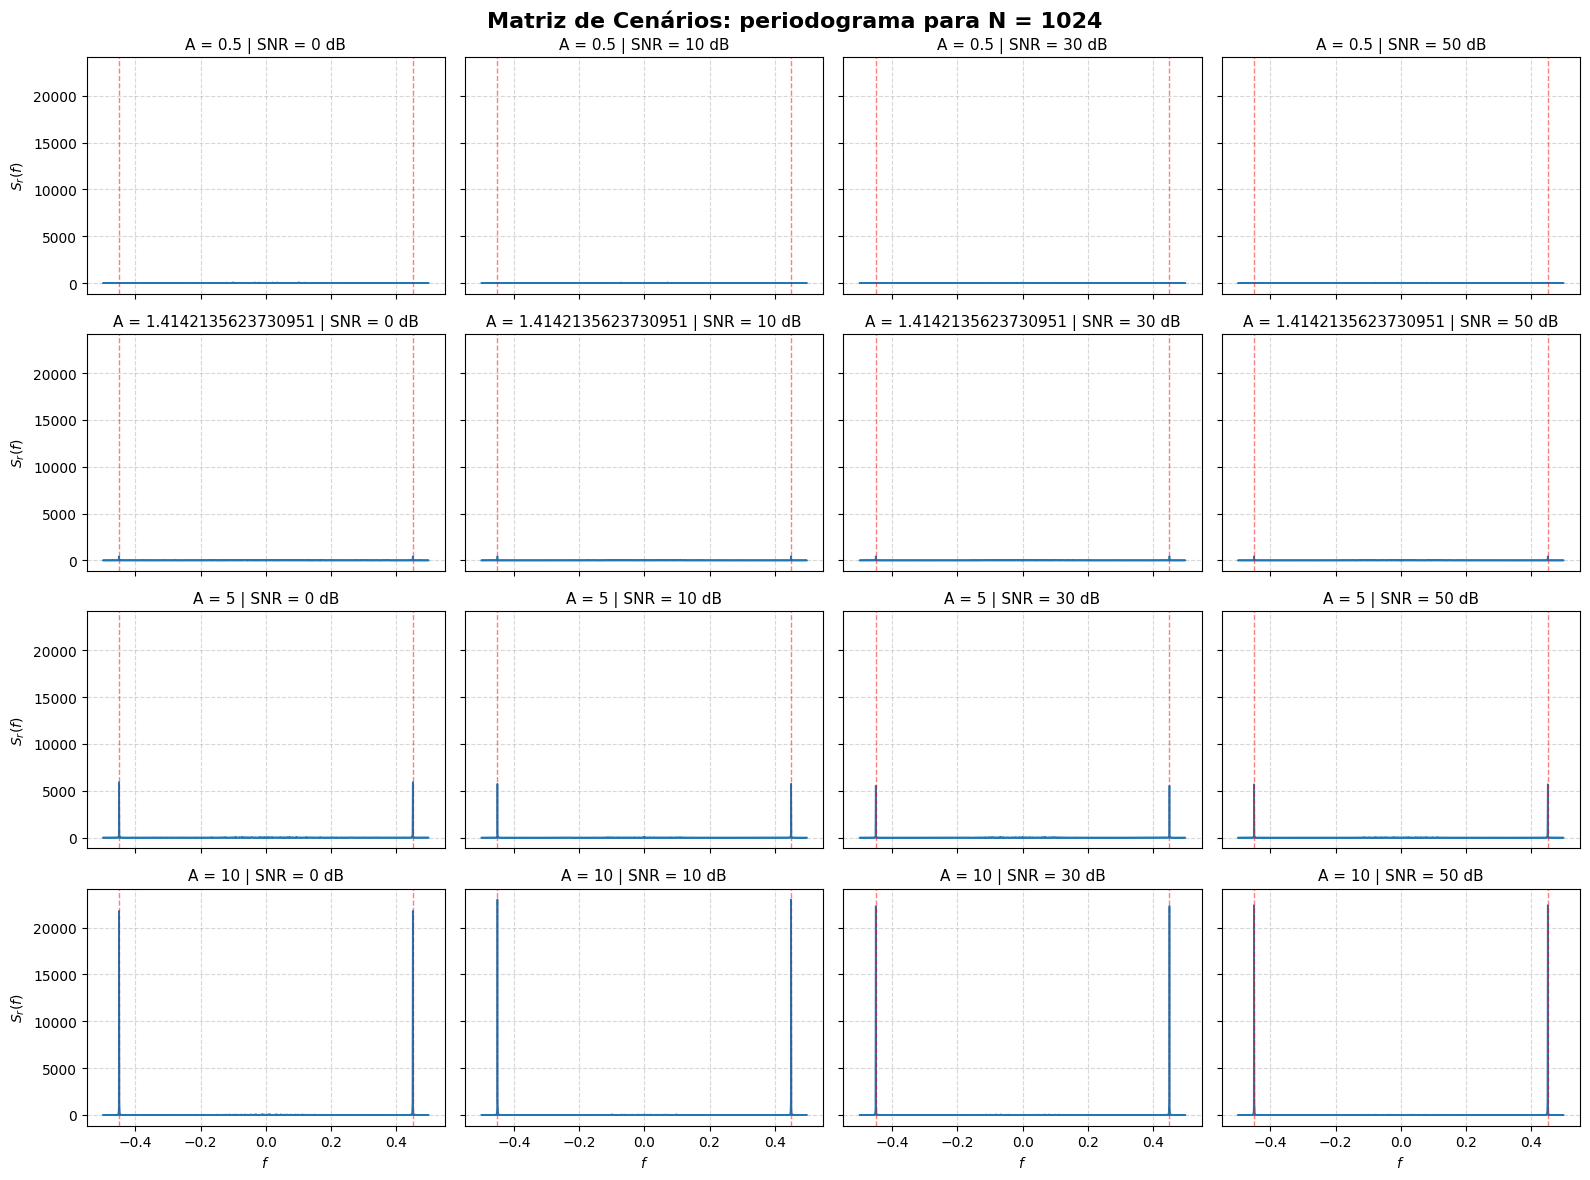

In [39]:
plot_scenario_matrix(list = periodograms_1024, N = 1024, method = "periodograma")

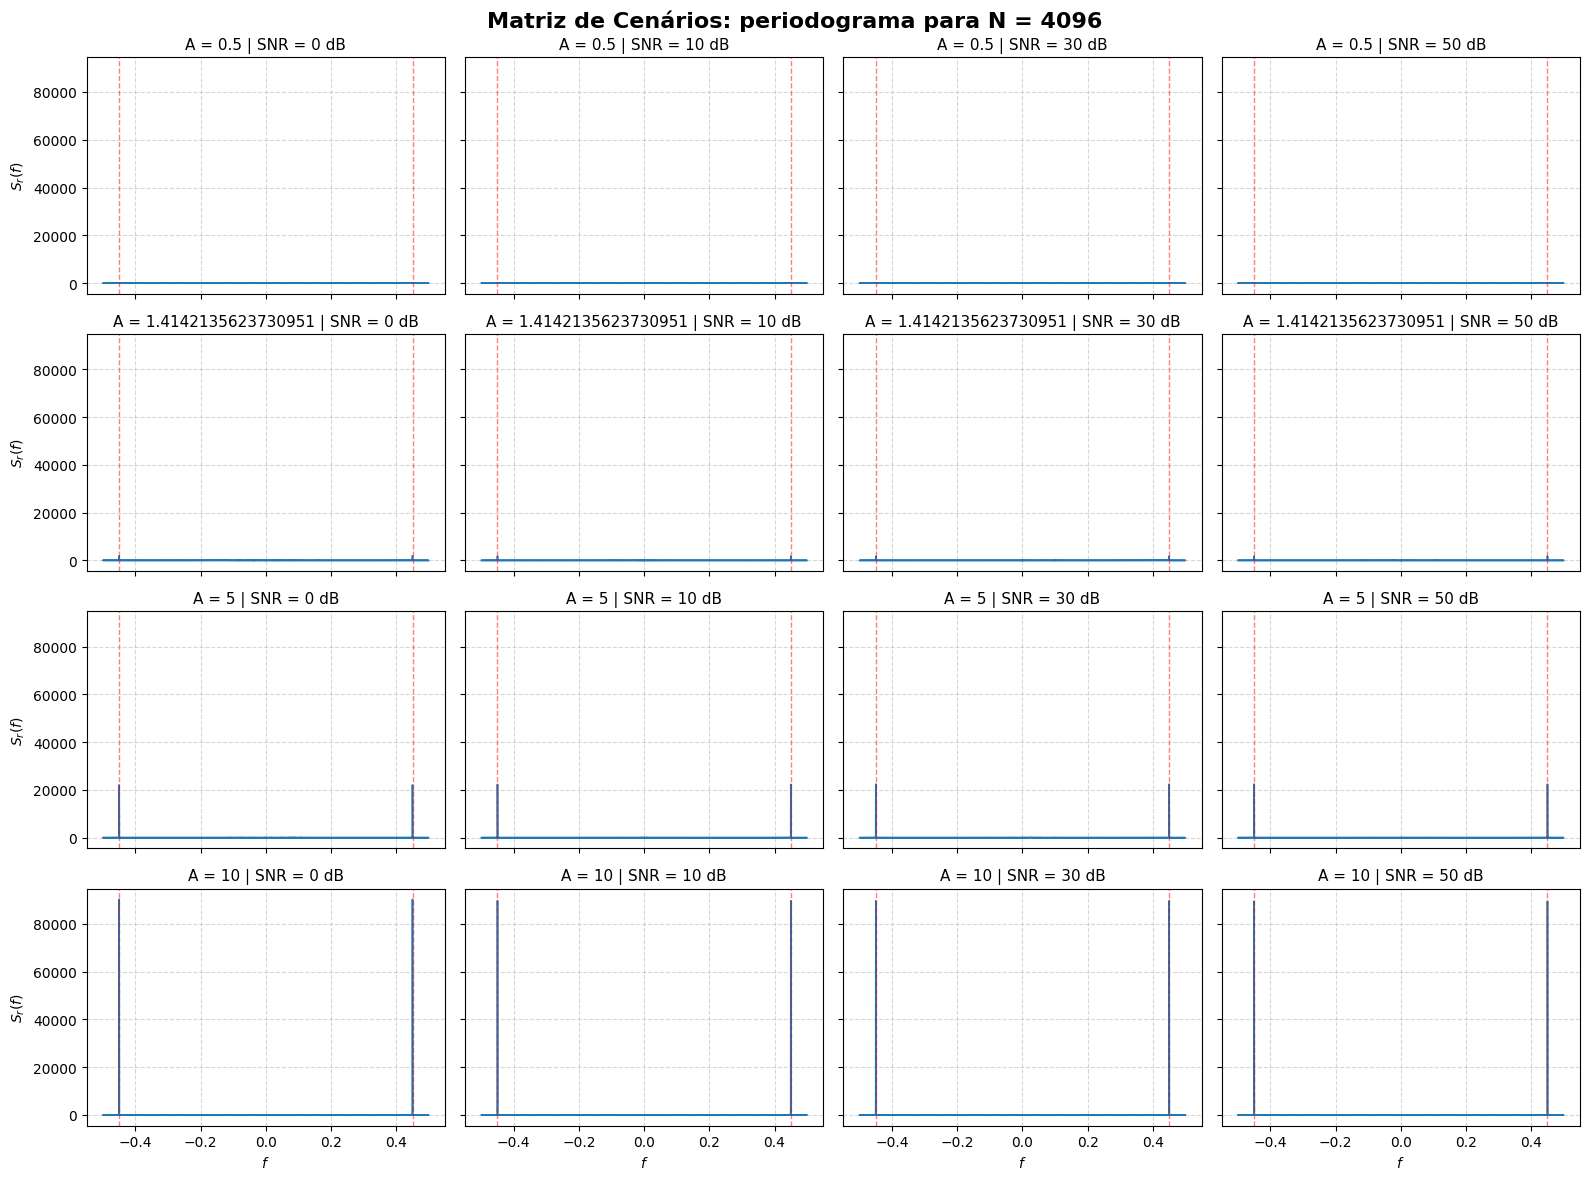

In [40]:
plot_scenario_matrix(periodograms_4096, N = 4096, method="periodograma")

#### Em escala logaritmica

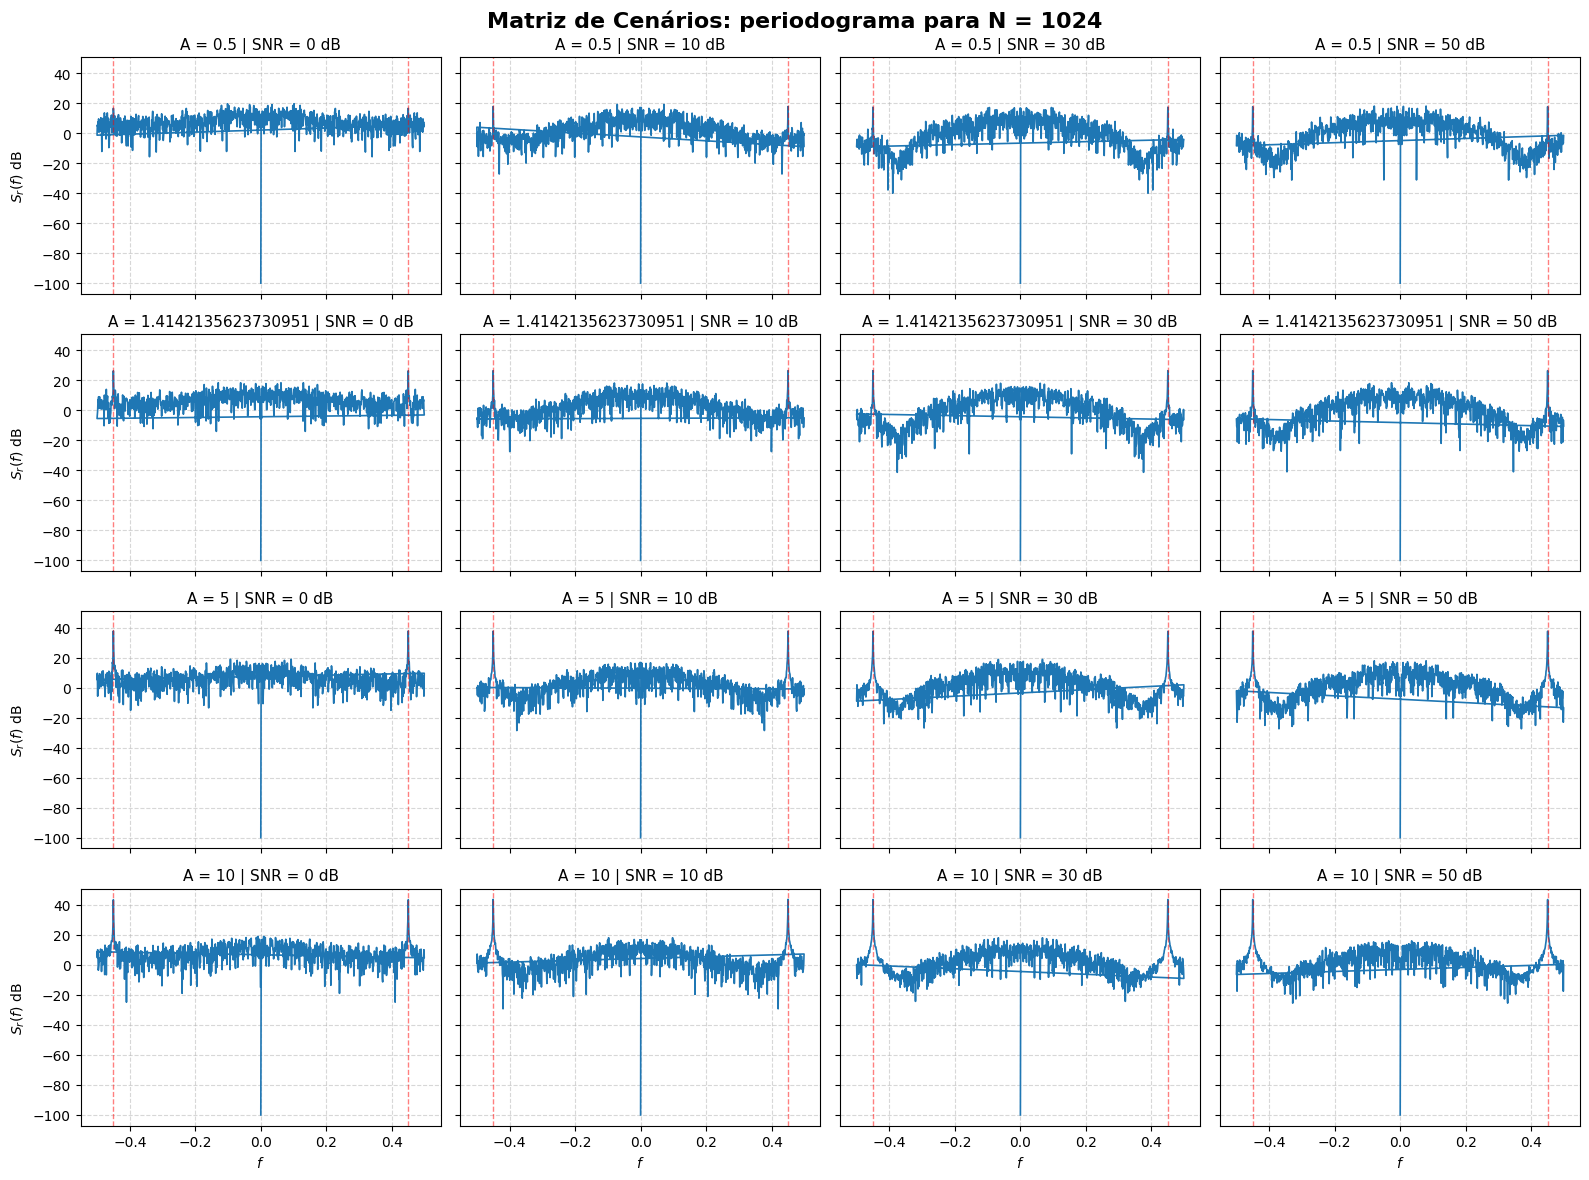

In [41]:
plot_scenario_matrix(list = periodograms_1024, N = 1024, method = "periodograma", scale = "db")

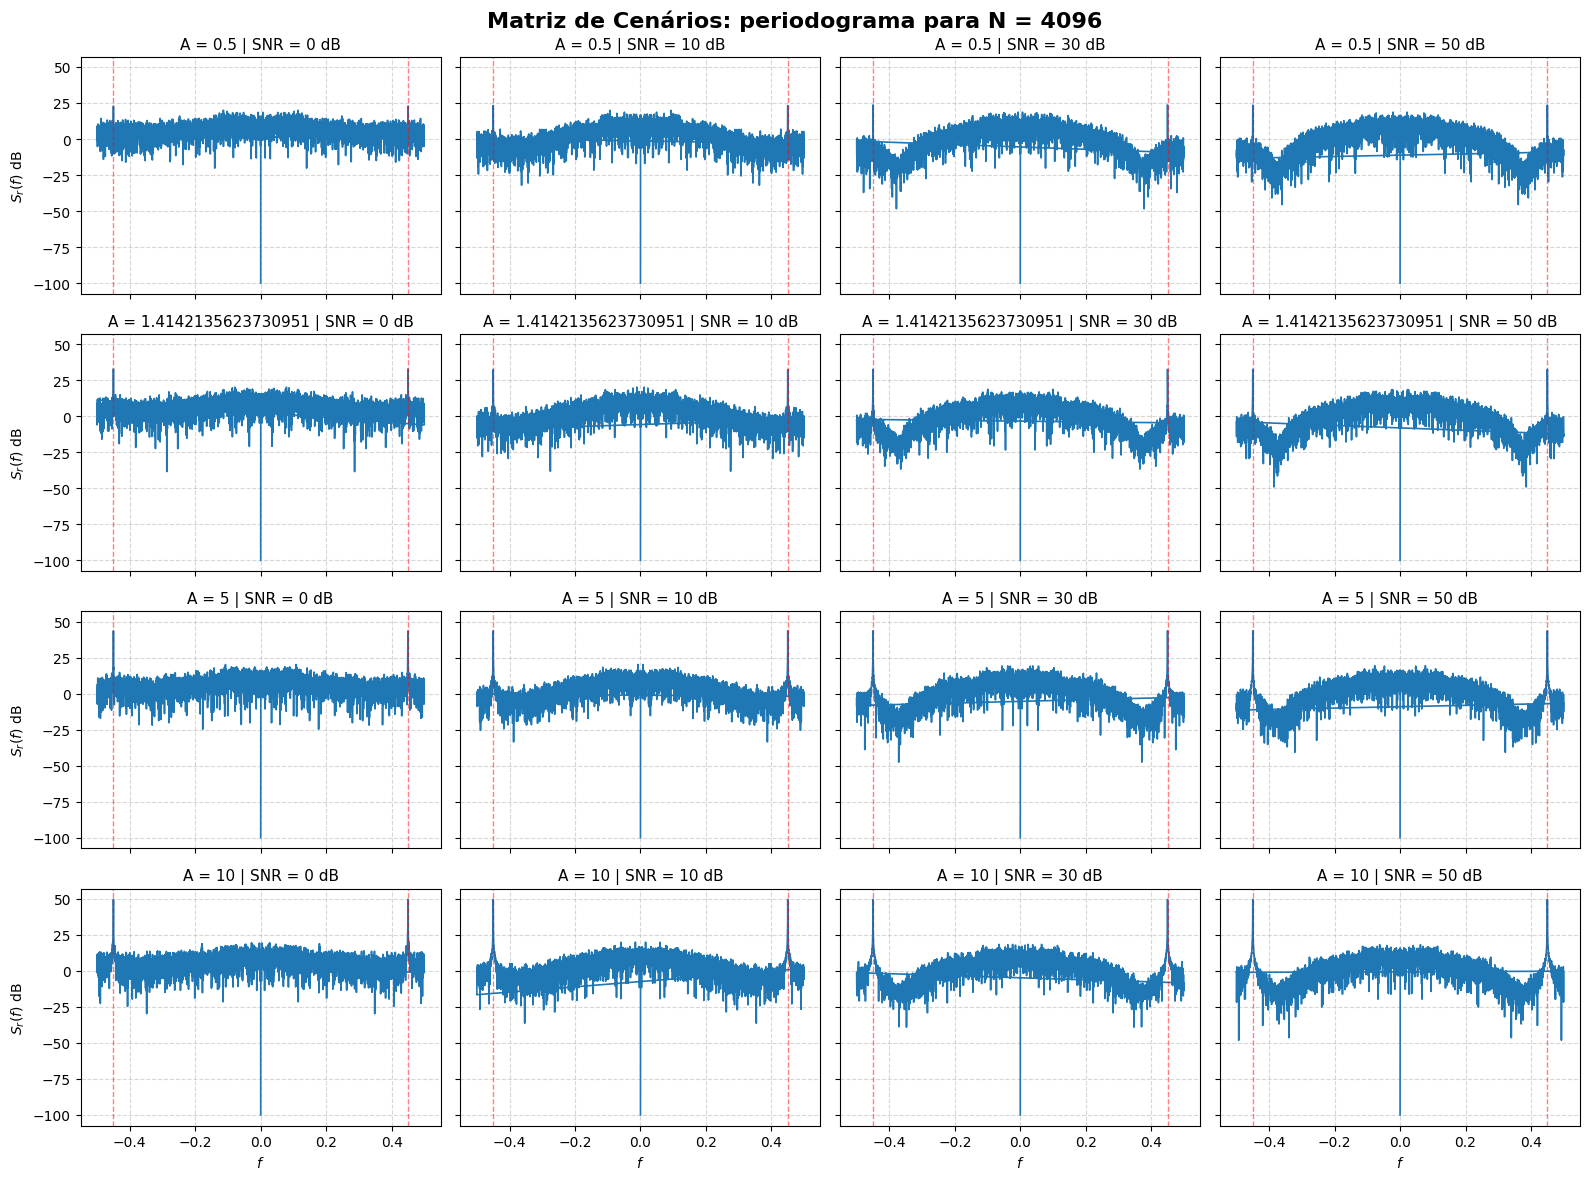

In [42]:

plot_scenario_matrix(list = periodograms_4096, N = 4096, method = "periodograma", scale = "db")

#### Calculando e plotando o método de Welch

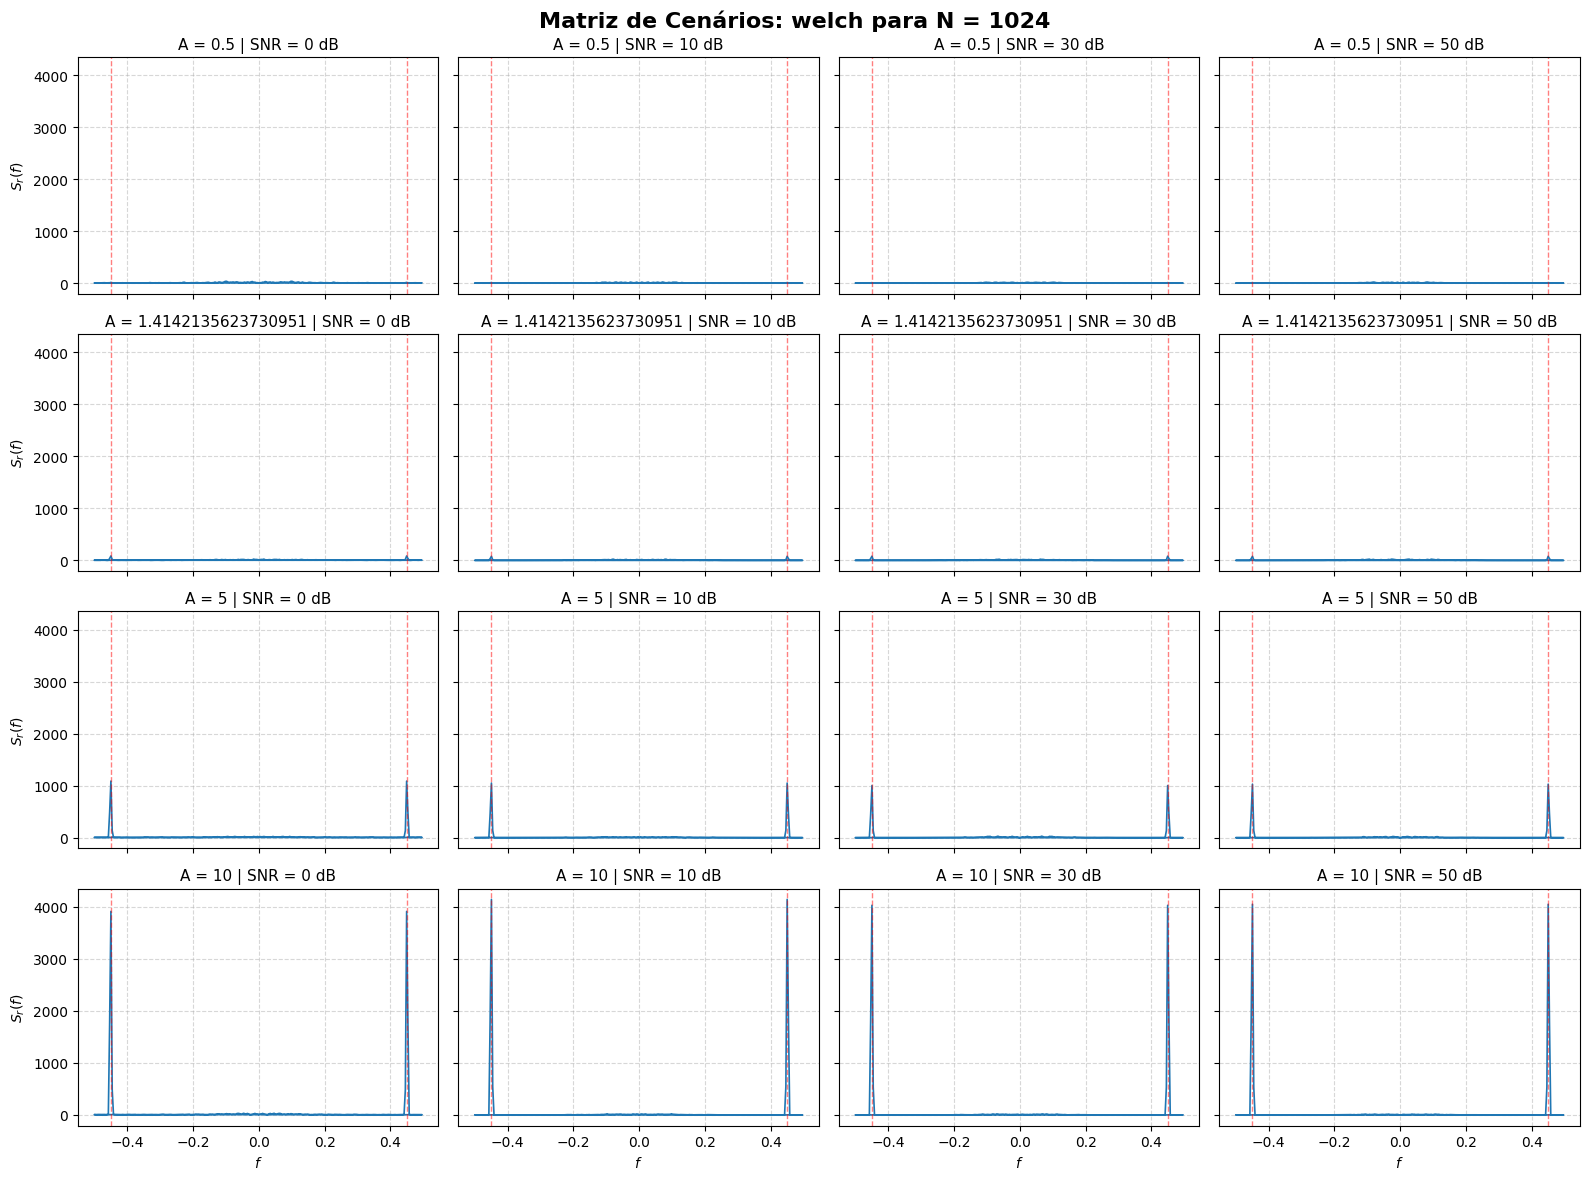

In [43]:
plot_scenario_matrix(list = welch_1024, N = 1024, method = "welch")

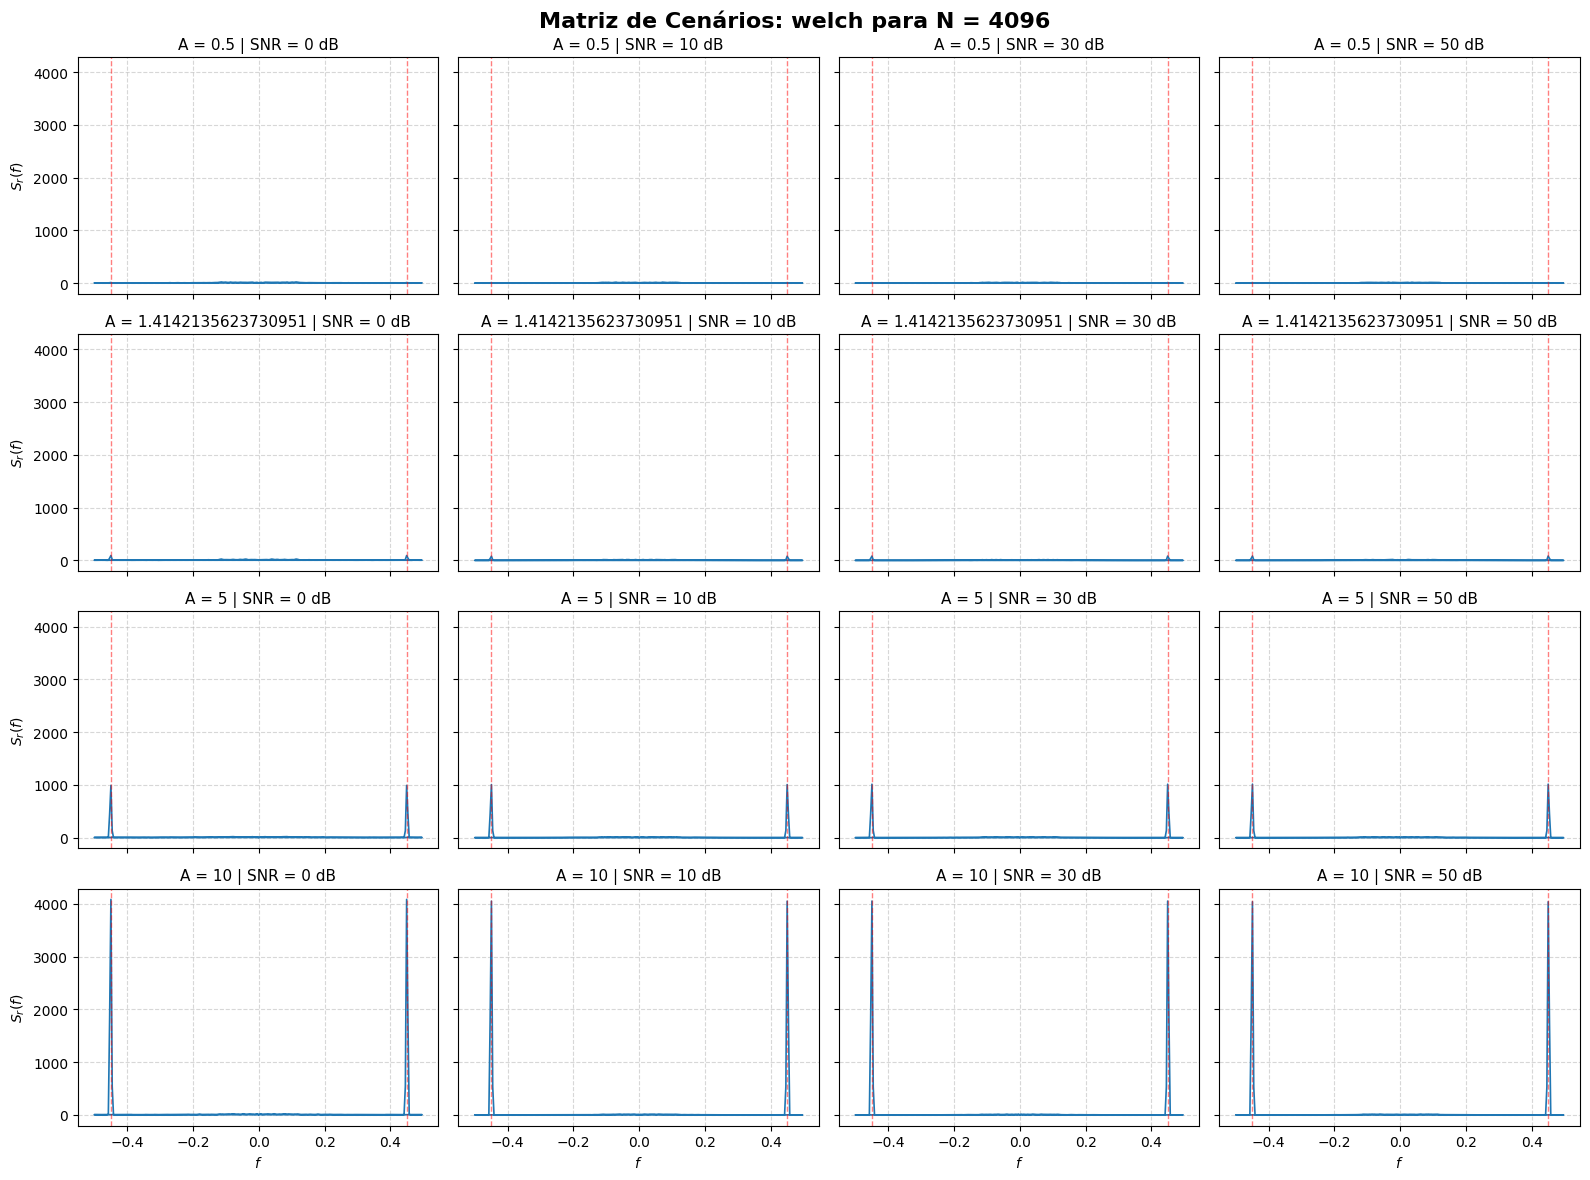

In [44]:
plot_scenario_matrix(list = welch_4096, N = 4096, method = "welch")

#### Em escala logaritmica

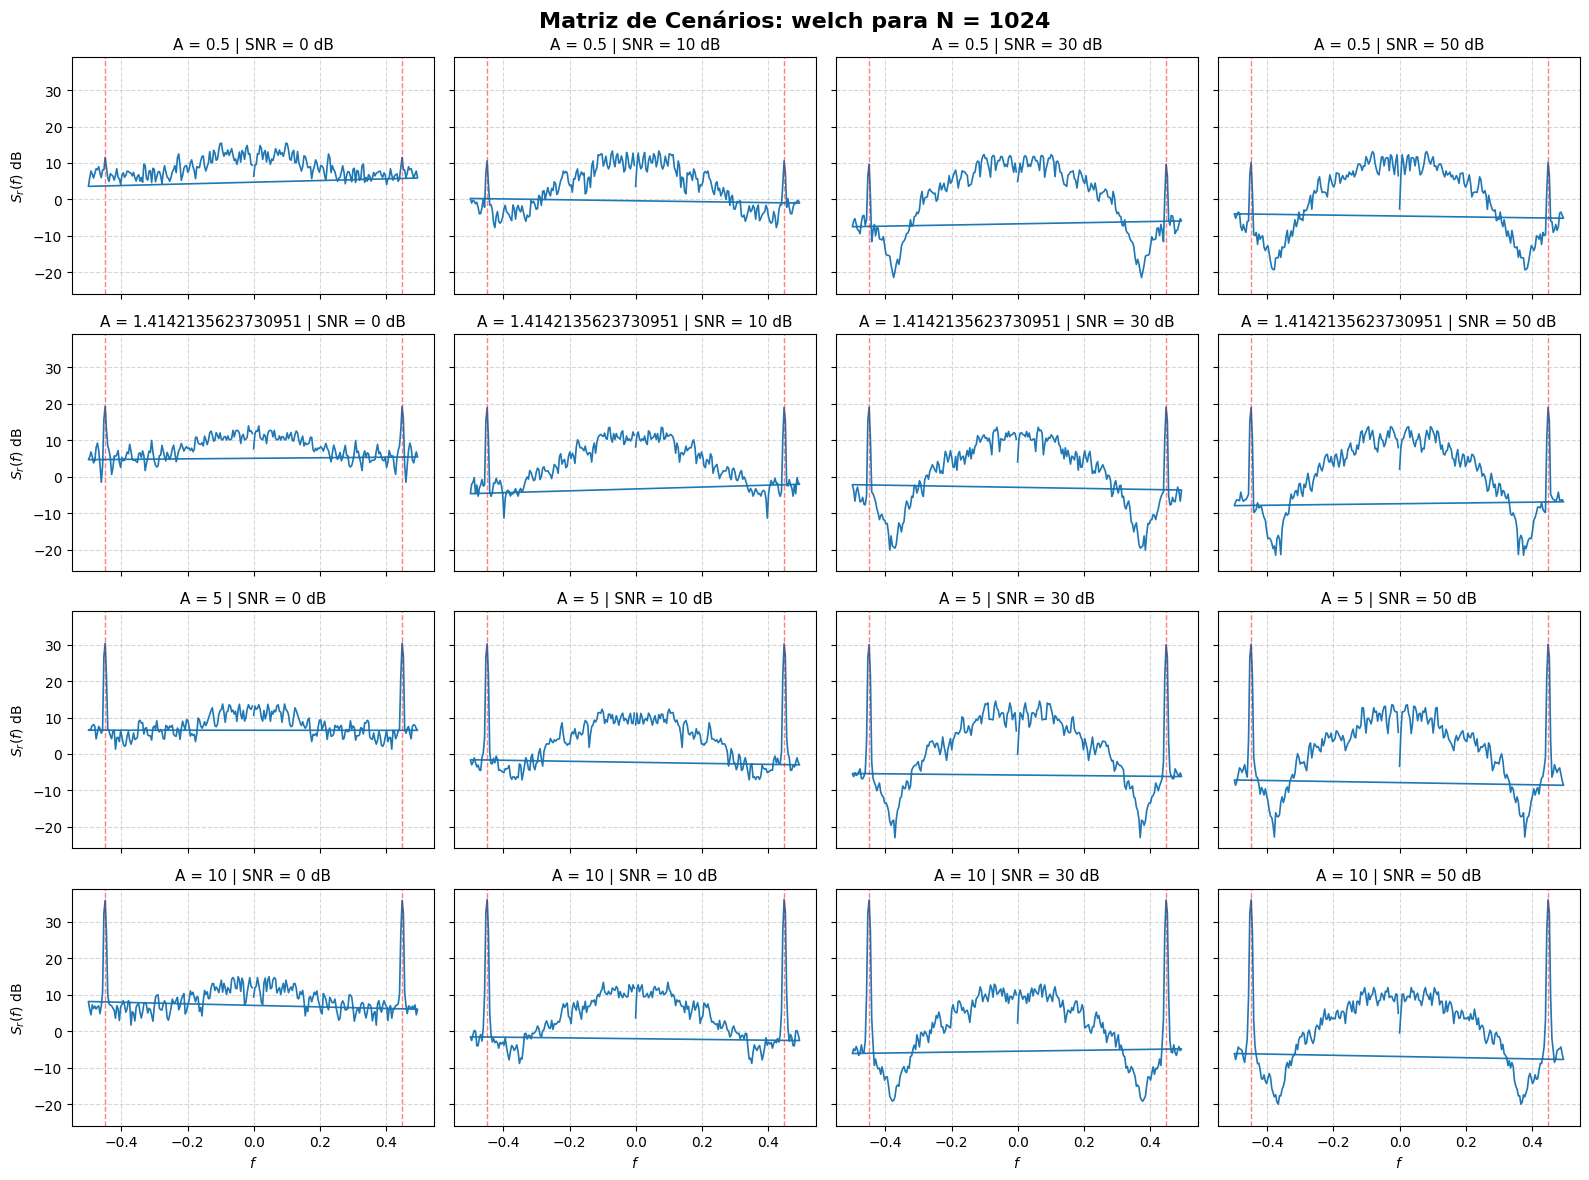

In [45]:
plot_scenario_matrix(list = welch_1024, N = 1024, method = "welch", scale = 'db')

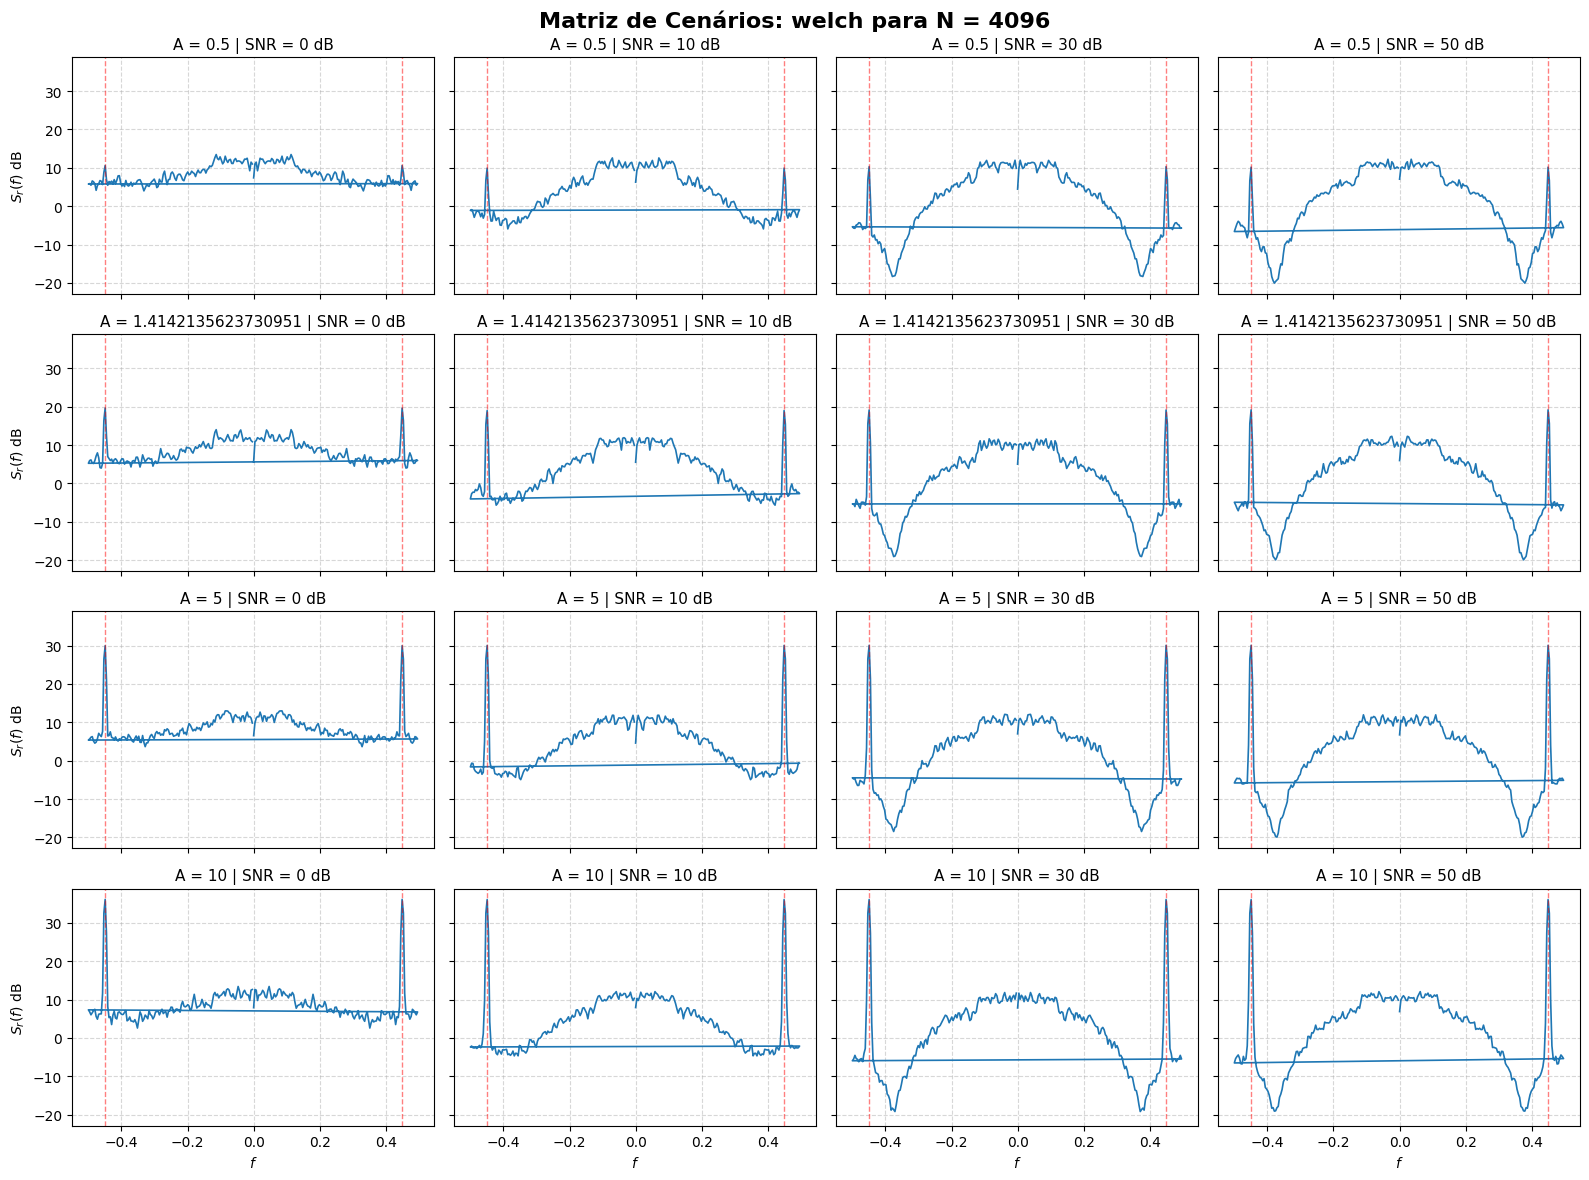

In [46]:
plot_scenario_matrix(list = welch_4096, N = 4096, method = "welch", scale = 'db')

## 4a questão

### Comparando as DEP adquiridas anteriormente com a teórica dada por:
$$S_r(f) = |H(f)|² S_{xx}(f) + \frac{A²}{4}[\delta(f-f_0) + \delta(f+f_0)] + \sigma_w^2$$

In [19]:
def Sx(f):
    return 1 /(np.abs(1 - a1 * np.exp(-j*2*np.pi*f)) - a2 * np.exp(-j*4*np.pi*f)) ** 2